# Coppuccino on a Galactic Binary Posterior

This notebook fits a copula normalizing flow to MCMC posterior samples from a
galactic binary gravitational-wave source (LDC2A challenge, source #7).

1. Load the posterior samples (8 source parameters) and handle the periodic phase
2. Fit a copula normalizing flow
3. Sample from the fitted flow and compare marginals
4. Corner plot of the full 8D posterior
5. Compare pairwise correlations
6. Evaluate log probabilities
7. Save and load the model

> The extra packages used here (`pandas`, `corner`, `pyarrow`, `matplotlib`) are
> not coppuccino dependencies. Install them with `pip install -r requirements.txt`.

In [1]:
import numpy as np
import pandas as pd
import corner
from matplotlib import pyplot as plt
from coppuccino import normalizing_flows_fit, sample, log_prob, save_flow, load_flow

## 1. Load the posterior and handle the phase wrap

In [2]:
posterior = pd.read_feather("./data/LDC2A_00000007_posterior.feather")

params = [
    "Frequency",
    "Frequency Derivative",
    "Amplitude",
    "Ecliptic Longitude",
    "sinlat",
    "cosinc",
    "Initial Phase",
    "Polarization",
]
data = posterior[params].to_numpy()
n_samples = data.shape[0]

print(f"Data shape: {data.shape}")
posterior.head()

Data shape: (3600, 8)


,Group ID,Confidence,SNR,Amplitude,Frequency,Frequency Derivative,Initial Phase,cosinc,Polarization,Ecliptic Longitude,sinlat,Ecliptic Latitude,coslat,Inclination,Parent,opt_snr
0,7.0,1.0,49.413277,4.919698e-21,0.000571,2.178367e-16,0.012636,-0.406781,1.811550,3.650015,-0.296126,-0.300634,-0.296126,1.989724,None,47.567859
1,7.0,1.0,49.728308,5.375559e-21,0.000571,5.545693e-17,3.072001,-0.345436,0.202917,3.662744,-0.296894,-0.301438,-0.296894,1.923499,None,47.906776
2,7.0,1.0,50.779878,5.656702e-21,0.000571,7.665149e-17,3.130777,-0.321993,0.210332,3.672274,-0.305166,-0.310113,-0.305166,1.898630,None,48.921208
3,7.0,1.0,49.316981,5.357642e-21,0.000571,2.188417e-16,3.195048,-0.342568,0.224870,3.643134,-0.344568,-0.351779,-0.344568,1.920445,None,47.505783
4,7.0,1.0,50.094660,5.457370e-21,0.000571,-5.190098e-17,6.166799,-0.340866,1.769427,3.664789,-0.331268,-0.337647,-0.331268,1.918634,None,48.260127


`Initial Phase` is an angle, periodic on $[0, 2\pi]$. This posterior has a mode
that straddles the $0/2\pi$ boundary — samples pile up near *both* 0 and $2\pi$ —
so the flow sees one physical mode as two half-modes at opposite ends of the
range, which distorts the joint (correlation) structure.

The tempting fix — telling the flow the support is $[0, 2\pi]$ via `prior_bounds`
— does **not** help here: the samples already span the full range, so pinning the
edges changes nothing. What works is **recentering** the phase by $\pi/2$
(mod $2\pi$) so the split mode becomes a single interior mode, then undoing the
shift after sampling. On a held-out split this raises the held-out log-probability
by ~0.25 nats and cuts the worst pairwise-correlation error from ~0.16 to ~0.12.

In [3]:
PHASE_IDX = params.index("Initial Phase")
TWO_PI = 2 * np.pi

def recenter(x):
    """Shift the periodic Initial Phase by +pi/2 (mod 2pi)."""
    y = x.copy()
    y[:, PHASE_IDX] = (x[:, PHASE_IDX] + np.pi / 2) % TWO_PI
    return y

def unrecenter(x):
    """Inverse of recenter: shift Initial Phase back by -pi/2 (mod 2pi)."""
    y = x.copy()
    y[:, PHASE_IDX] = (x[:, PHASE_IDX] - np.pi / 2) % TWO_PI
    return y

data_fit = recenter(data)

## 2. Fit a copula normalizing flow

In [4]:
flow = normalizing_flows_fit(data_fit, max_epochs=200, rng_seed=42)

## 3. Sample from the flow and compare marginals

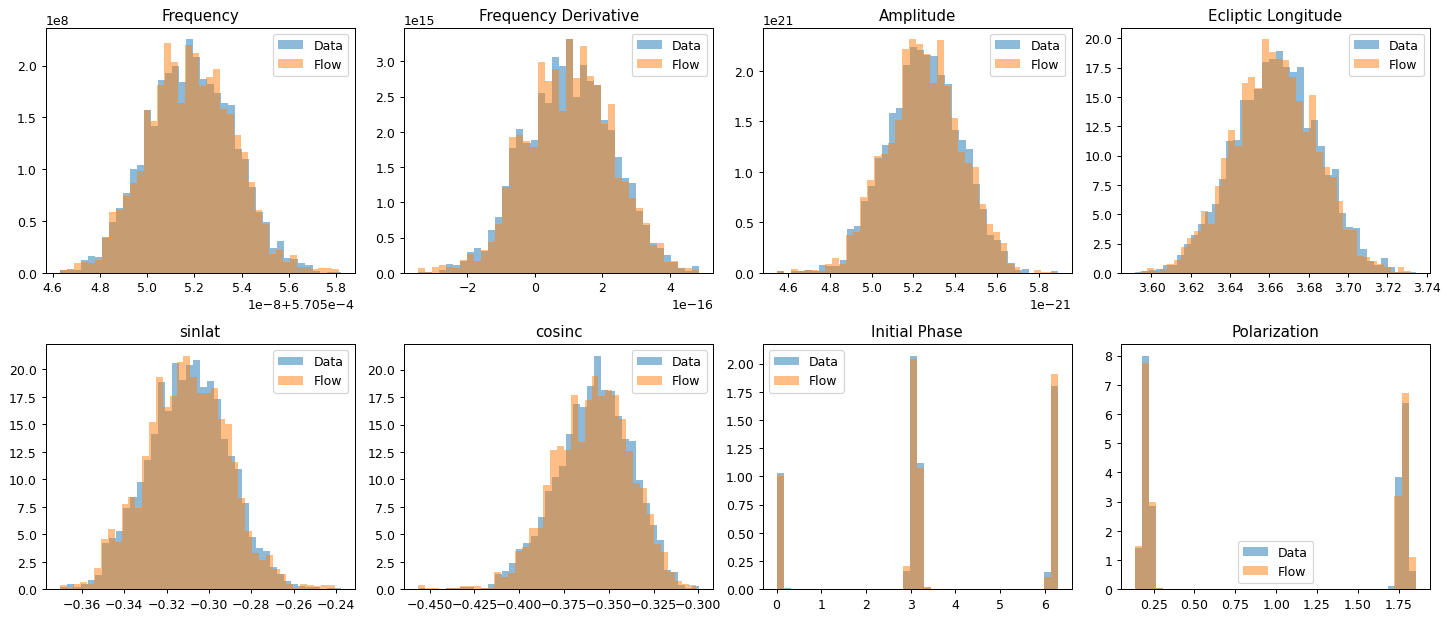

In [5]:
# sample() returns recentered coordinates; map back to the original frame
flow_samples = unrecenter(sample(flow, n_samples=n_samples, rng_seed=123))

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for i, ax in enumerate(axes.flat):
    ax.hist(data[:, i], bins=40, density=True, alpha=0.5, label="Data")
    ax.hist(flow_samples[:, i], bins=40, density=True, alpha=0.5, label="Flow")
    ax.set_title(params[i])
    ax.legend()
plt.tight_layout()
plt.show()

## 4. Corner plot of the full 8D posterior

Overlay the flow samples on the original posterior across all 8 dimensions.

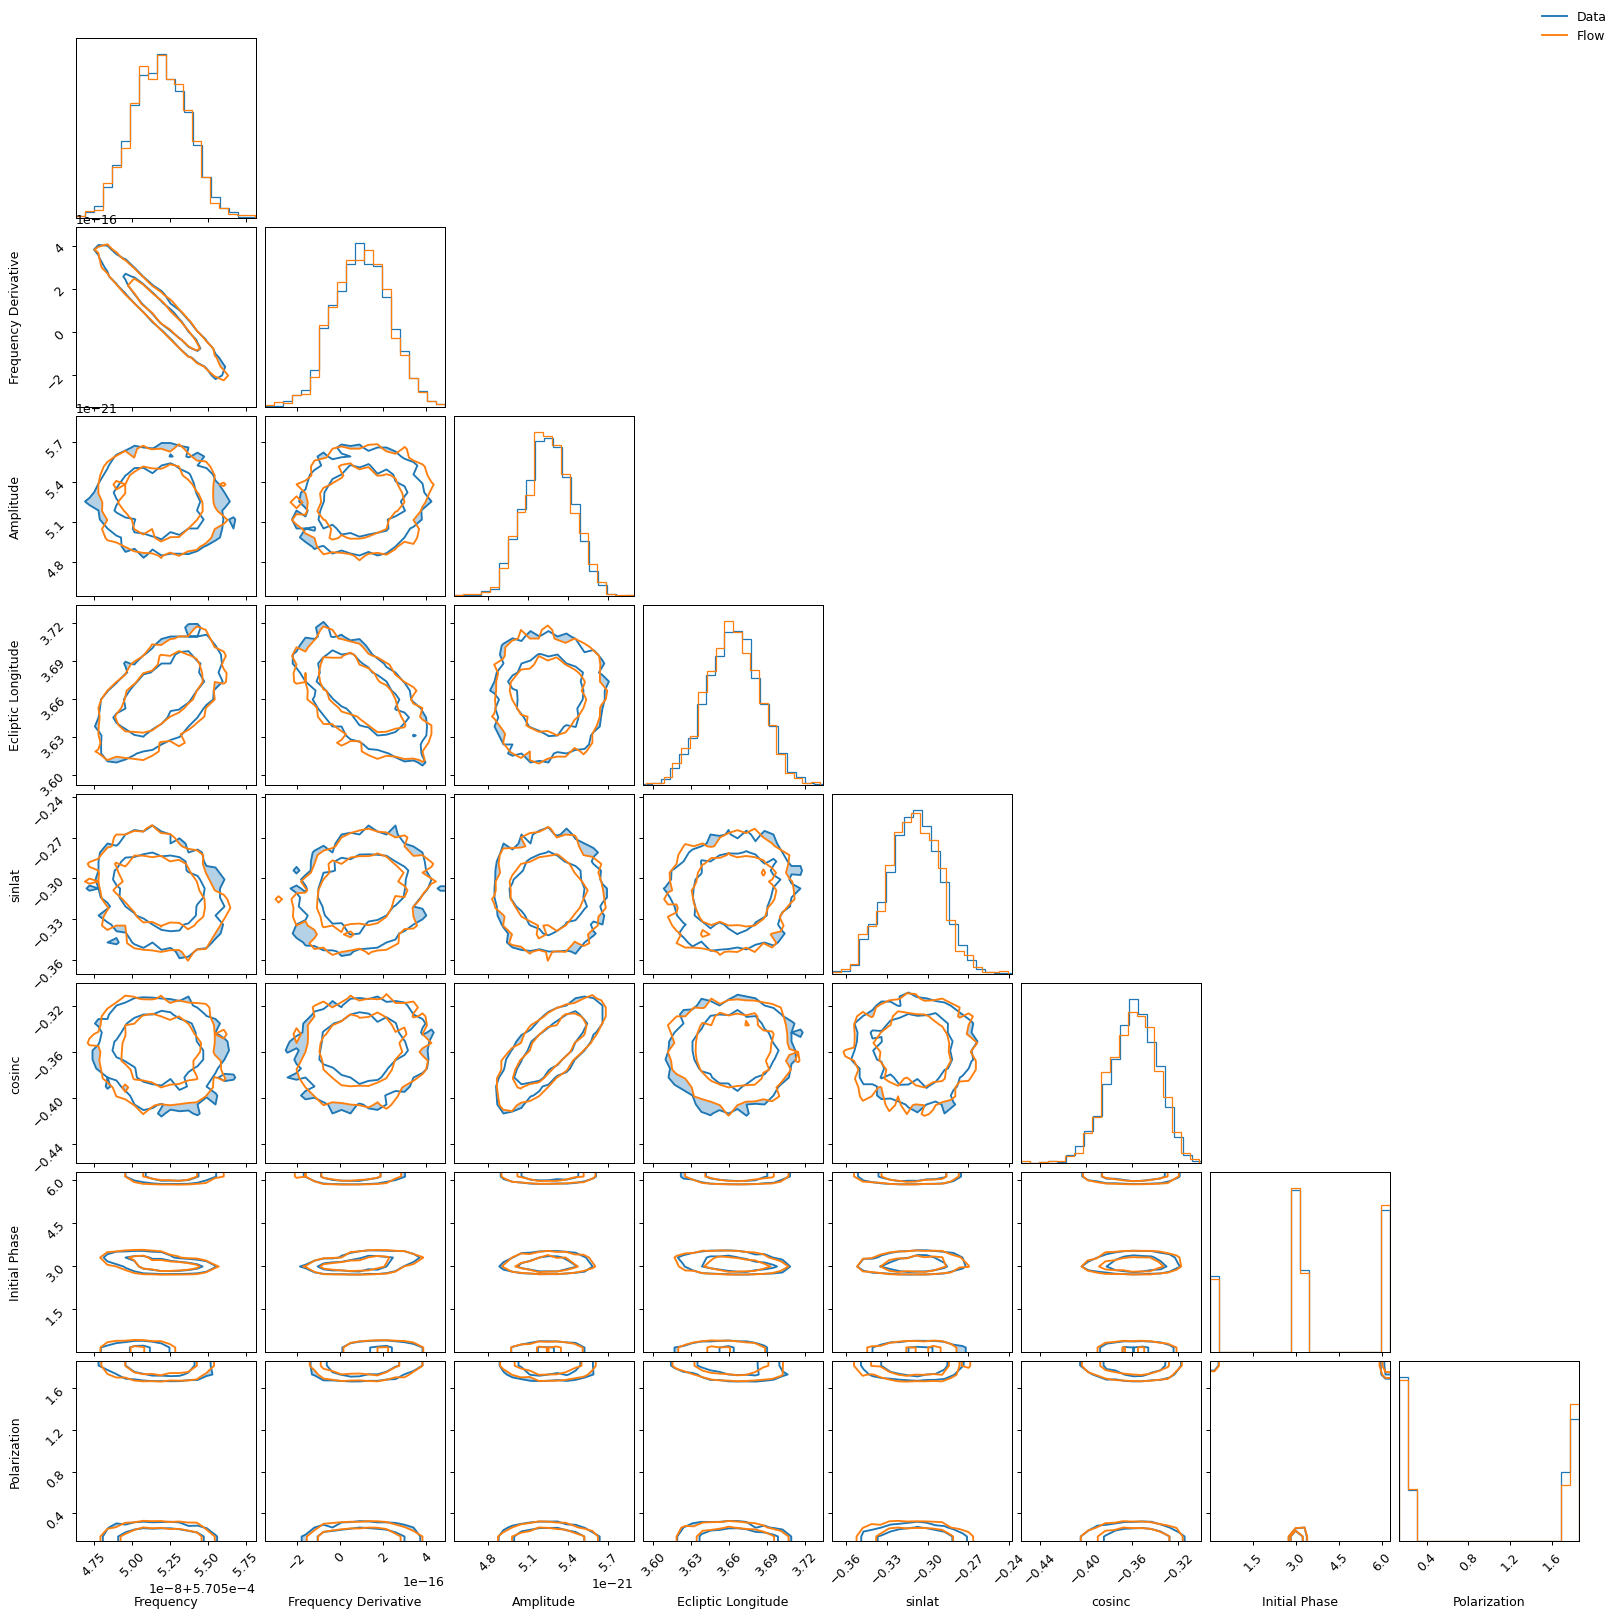

In [6]:
fig = corner.corner(
    data,
    labels=params,
    color="C0",
    hist_kwargs={"density": True},
    plot_datapoints=False,
    plot_density=False,
    fill_contours=True,
    levels=(0.68, 0.95),
)
corner.corner(
    flow_samples,
    labels=params,
    color="C1",
    hist_kwargs={"density": True},
    plot_datapoints=False,
    plot_density=False,
    fill_contours=False,
    levels=(0.68, 0.95),
    fig=fig,
)
fig.legend(
    handles=[
        plt.Line2D([], [], color="C0", label="Data"),
        plt.Line2D([], [], color="C1", label="Flow"),
    ],
    loc="upper right",
    frameon=False,
)
plt.show()

## 5. Compare pairwise correlations

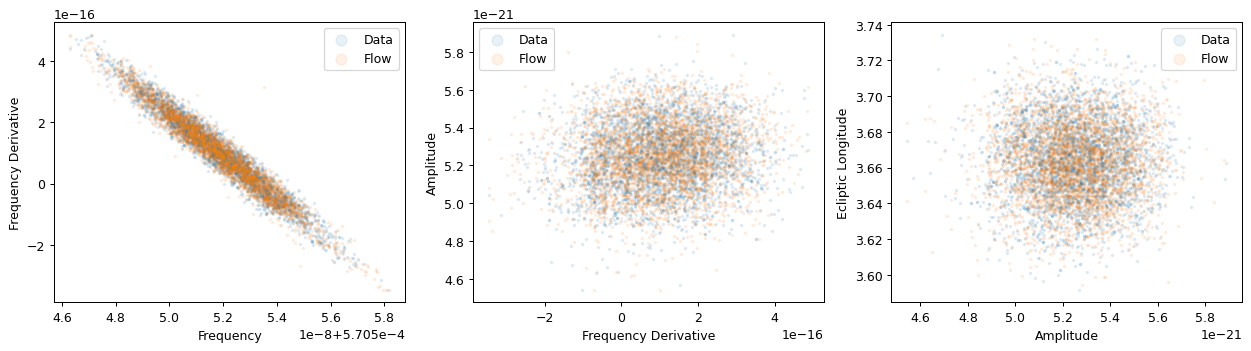

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
pairs = [(0, 1), (1, 2), (2, 3)]
for ax, (i, j) in zip(axes, pairs):
    ax.scatter(data[:, i], data[:, j], alpha=0.1, s=3, label="Data")
    ax.scatter(flow_samples[:, i], flow_samples[:, j], alpha=0.1, s=3, label="Flow")
    ax.set_xlabel(params[i])
    ax.set_ylabel(params[j])
    ax.legend(markerscale=5)
plt.tight_layout()
plt.show()

## 6. Evaluate log probabilities

In [8]:
# recenter() has unit Jacobian, so this is the flow density at the original points
log_probs = log_prob(flow, recenter(data[:100]))
print(f"Mean log prob on training data: {np.mean(log_probs):.3f}")
print(f"Std log prob: {np.std(log_probs):.3f}")

Mean log prob on training data: 116.431
Std log prob: 5.286


## 7. Save and load the model

In [9]:
save_flow(flow, "galactic_binary_flow.pkl")
loaded_flow = load_flow("galactic_binary_flow.pkl")

# Verify the loaded flow reproduces the original flow's samples exactly
loaded_samples = sample(loaded_flow, n_samples=1000, rng_seed=99)
original_samples = sample(flow, n_samples=1000, rng_seed=99)
print(f"Max difference between original and loaded samples: {np.max(np.abs(loaded_samples - original_samples)):.2e}")

Max difference between original and loaded samples: 0.00e+00
